In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
import corner
import h5py

In [7]:
f = h5py.File('sample_2e7_design_precessing_higherordermodes_3detectors.h5', 'r')

In [9]:
list(f.keys())

['chi1x',
 'chi1y',
 'chi1z',
 'chi2x',
 'chi2y',
 'chi2z',
 'dec',
 'det',
 'iota',
 'mtot',
 'psi',
 'q',
 'ra',
 'snr',
 'z']

In [17]:
chi1x = f['chi1x'][:1000]
chi1y = f['chi1y'][:1000]
chi1z = f['chi1z'][:1000]
chi2x = f['chi2x'][:1000]
chi2y = f['chi2y'][:1000]
chi2z = f['chi2z'][:1000]
iota = f['iota'][:1000]
mtot = f['mtot'][:1000]
psi = f['psi'][:1000]
q = f['q'][:1000]
ra = f['ra'][:1000]
dec = f['dec'][:1000]
z = f['z'][:1000]
det = f['det'][:1000] #labels: 0=not detected, 1=detected

In [28]:
# LIGO doesn't see the source if snr < 12

X = np.array([chi1x, chi1y, chi1z, chi2x, chi2y, chi2z, iota, mtot, psi, q, ra, dec, z])
Xd = X.T
Xd.shape

(1000, 13)

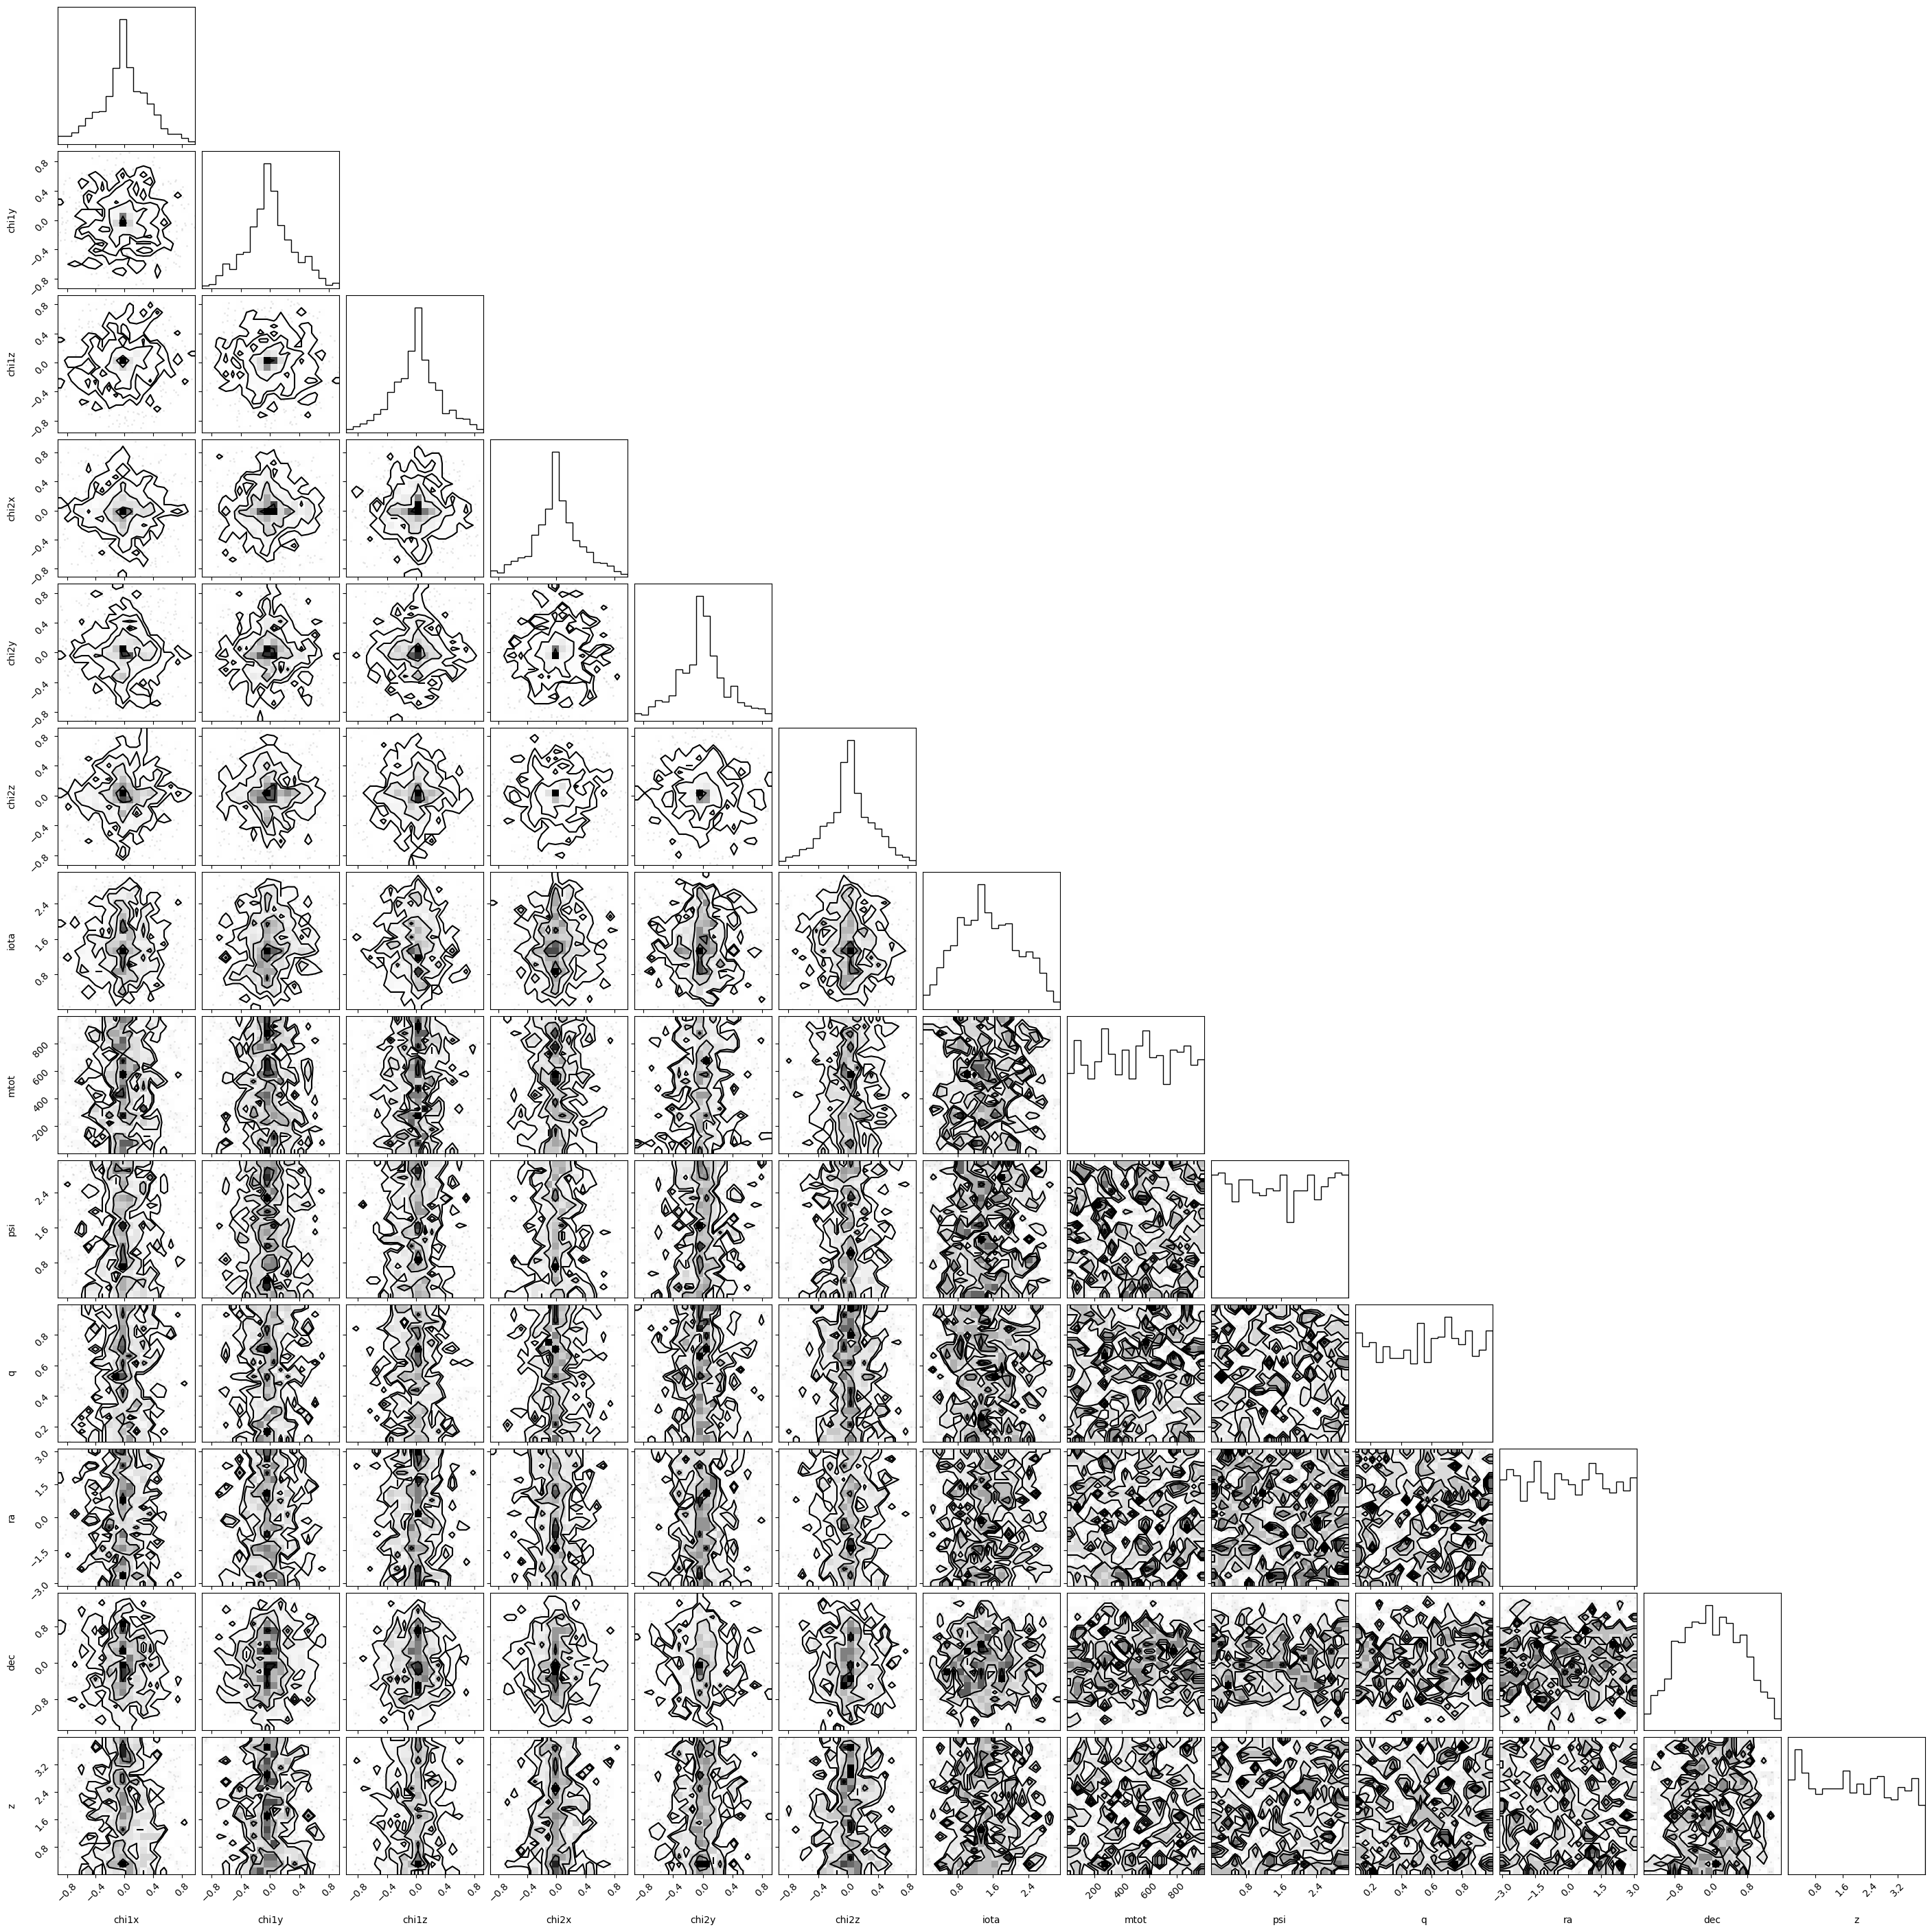

In [29]:
fig = corner.corner(Xd, labels=['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'iota', 'mtot', 'psi', 'q', 'ra', 'dec', 'z'])

In [ ]:
# train decision tree
Nfeat = np.arange(1, 13)
depths = np.arange(5, 12)
classifiers = []
predictions = []
X_test, X_train, y_test, y_train = 
for depth in depths:
    classifiers.append([])
    predictions.append([])
    for nc in Nfeat:
        clf = DecisionTreeClassifier(random_state=0, max_depth=depth,
                                     criterion='entropy')
        clf.fit(X_train[:, :nc], y_train)
        y_pred = clf.predict(X_test[:, :nc])

        classifiers[-1].append(clf)
        predictions[-1].append(y_pred)        